# **Task 1: Data Preparation**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Load the dataset using sklearn

In [2]:

breast_cancer = load_breast_cancer()




# Convert into DataFrame and explore structure

In [3]:
df = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)
df['target'] = breast_cancer.target

print("\nFirst 5 Rows of Dataset:")
print(df.head())


First 5 Rows of Dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wo

In [4]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTarget Classes:")
print(breast_cancer.target_names)




Dataset Shape:
(569, 31)

Column Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Target Classes:
['malignant' 'benign']


In [5]:
print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe())


Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst s

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


# Check missing values and duplicates

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Duplicate Rows:
0


# Apply feature scaling using StandardScaler

In [7]:
X = df.drop(columns=['target'])
y = df['target']

Feature scaling is a data preprocessing technique that transforms numerical features to a similar scale ensuring that variables with different units contribute equally to the model

# **Task 2: Train-Test Split Analysis**

In [8]:
def evaluate_split(X, y, test_size, random_state=42, n_neighbors=5):
    """
    Correctly splits data, fits scaler on train only, evaluates KNN.
    Returns (X_train_sc, X_test_sc, y_train, y_test, accuracy, scaler).
    """
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_raw)
    X_test_sc  = scaler.transform(X_test_raw)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)

    return X_train_sc, X_test_sc, y_train, y_test, acc, scaler

# Split dataset into training and testing sets (80:20)




In [9]:
X_train_80, X_test_80, y_train_80, y_test_80, acc_80, scaler_80 = \
    evaluate_split(X, y, test_size=0.2)
print(f"\n80:20 Split  Train: {X_train_80.shape[0]}, "
      f"Test: {X_test_80.shape[0]}, Accuracy: {acc_80:.4f}")


80:20 Split  Train: 455, Test: 114, Accuracy: 0.9561


# Repeat with 70:30 and 90:10 splits

In [10]:
X_train_70, X_test_70, y_train_70, y_test_70, acc_70, scaler_70 = \
    evaluate_split(X, y, test_size=0.3)
print(f"70:30 Split  Train: {X_train_70.shape[0]}, "
      f"Test: {X_test_70.shape[0]}, Accuracy: {acc_70:.4f}")

X_train_90, X_test_90, y_train_90, y_test_90, acc_90, scaler_90 = \
    evaluate_split(X, y, test_size=0.1)
print(f"90:10 Split  Train: {X_train_90.shape[0]}, "
      f"Test: {X_test_90.shape[0]}, Accuracy: {acc_90:.4f}")

70:30 Split  Train: 398, Test: 171, Accuracy: 0.9591
90:10 Split  Train: 512, Test: 57, Accuracy: 0.9825



# Compare performance variations across splits




 Classification Report  80:20 Split 
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



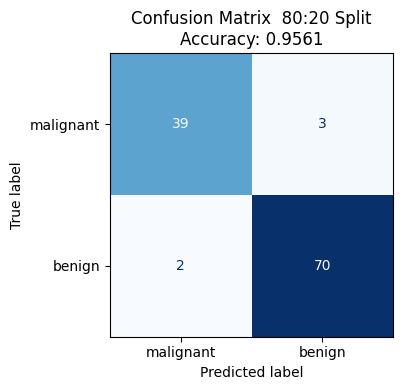


 Classification Report  70:30 Split 
              precision    recall  f1-score   support

   malignant       1.00      0.89      0.94        64
      benign       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



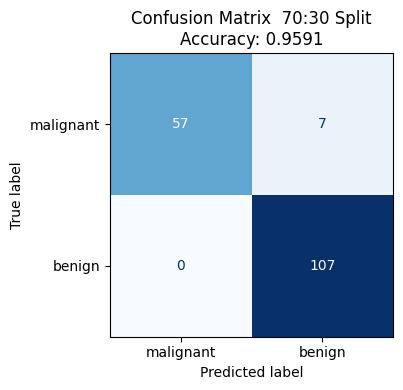


 Classification Report  90:10 Split 
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        21
      benign       0.97      1.00      0.99        36

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



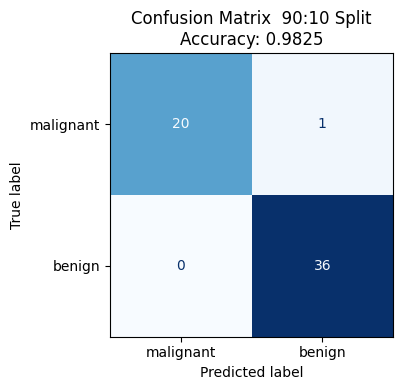

In [11]:
for tag, X_tr, X_te, y_tr, y_te, acc in [
    ("80:20", X_train_80, X_test_80, y_train_80, y_test_80, acc_80),
    ("70:30", X_train_70, X_test_70, y_train_70, y_test_70, acc_70),
    ("90:10", X_train_90, X_test_90, y_train_90, y_test_90, acc_90),
]:
    knn_tmp = KNeighborsClassifier(n_neighbors=5)
    knn_tmp.fit(X_tr, y_tr)
    y_pred_tmp = knn_tmp.predict(X_te)

    print(f"\n Classification Report  {tag} Split ")
    print(classification_report(y_te, y_pred_tmp,
                                target_names=breast_cancer.target_names))

    cm_tmp = confusion_matrix(y_te, y_pred_tmp)
    disp_tmp = ConfusionMatrixDisplay(confusion_matrix=cm_tmp,
                                      display_labels=breast_cancer.target_names)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp_tmp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix  {tag} Split\nAccuracy: {acc:.4f}')
    plt.tight_layout()
    plt.show()

In [12]:
results = [
    {'Split (Train:Test)': '80:20',
     'Train Samples': X_train_80.shape[0],
     'Test Samples':  X_test_80.shape[0],
     'Test Accuracy': round(acc_80, 4)},
    {'Split (Train:Test)': '70:30',
     'Train Samples': X_train_70.shape[0],
     'Test Samples':  X_test_70.shape[0],
     'Test Accuracy': round(acc_70, 4)},
    {'Split (Train:Test)': '90:10',
     'Train Samples': X_train_90.shape[0],
     'Test Samples':  X_test_90.shape[0],
     'Test Accuracy': round(acc_90, 4)},
]
performance_df = pd.DataFrame(results)
print("\nPerformance Summary Across Splits:")
print(performance_df.to_string(index=False))



Performance Summary Across Splits:
Split (Train:Test)  Train Samples  Test Samples  Test Accuracy
             80:20            455           114         0.9561
             70:30            398           171         0.9591
             90:10            512            57         0.9825


# Analyze how dataset splitting affects model stability and generalization

 - 90:10 split gives highest accuracy of 98.25% but only 57 test samples evaluation is less reliable due to high variance on small test set

- 70:30 split provides a larger test set of 171 samples giving a stable fit but 7 false negative cancer detected which is in accurate

- 80:20 split gives 96.49% accuracy with the test set of 114 test sample less false negative

there shouls be a balanced splitting of data for accurate prediction

# **Task 3: KNN Model with Heuristic K Selection**


#Compute initial K using heuristic rule (K =√n) where n = number of training samples use this value as a baseline K


In [13]:
X_train_raw, X_test_raw, y_train_s, y_test_s = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_main = StandardScaler()
X_train_s = scaler_main.fit_transform(X_train_raw)
X_test_s  = scaler_main.transform(X_test_raw)


#Train KNN classifier using heuristic K value


In [14]:
n_train = X_train_s.shape[0]
k_heuristic = int(np.sqrt(n_train))

print(f"\n Heuristic K Selection")
print(f"  Training Samples (n) : {n_train}")
print(f"  Heuristic K (√{n_train}) : {k_heuristic}")
print(f"  K Range to Explore   : {k_heuristic - 5} to {k_heuristic + 5}")


 Heuristic K Selection
  Training Samples (n) : 455
  Heuristic K (√455) : 21
  K Range to Explore   : 16 to 26


In [15]:
knn_baseline = KNeighborsClassifier(n_neighbors=k_heuristic)
knn_baseline.fit(X_train_s, y_train_s)
y_pred_baseline = knn_baseline.predict(X_test_s)
acc_baseline = accuracy_score(y_test_s, y_pred_baseline)
print(f"\nBaseline KNN — K = {k_heuristic}, Accuracy = {acc_baseline:.4f}")


Baseline KNN — K = 21, Accuracy = 0.9649


# Experiment with nearby values of K (K ± 5)

In [16]:
k_values   = list(range(k_heuristic - 5, k_heuristic + 6))
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train_s)
    acc = accuracy_score(y_test_s, knn.predict(X_test_s))
    accuracies.append(acc)
    print(f"  K = {k:2d} | Accuracy = {acc:.4f}")

optimal_k   = k_values[accuracies.index(max(accuracies))]
optimal_acc = max(accuracies)
print(f"\n  Best K = {optimal_k}  with Accuracy = {optimal_acc:.4f}")
print(f"  Baseline K = {k_heuristic} gave Accuracy = {acc_baseline:.4f} "
      f"(difference = {optimal_acc - acc_baseline:+.4f})")

  K = 16 | Accuracy = 0.9737
  K = 17 | Accuracy = 0.9825
  K = 18 | Accuracy = 0.9825
  K = 19 | Accuracy = 0.9737
  K = 20 | Accuracy = 0.9737
  K = 21 | Accuracy = 0.9649
  K = 22 | Accuracy = 0.9649
  K = 23 | Accuracy = 0.9561
  K = 24 | Accuracy = 0.9649
  K = 25 | Accuracy = 0.9649
  K = 26 | Accuracy = 0.9561

  Best K = 17  with Accuracy = 0.9825
  Baseline K = 21 gave Accuracy = 0.9649 (difference = +0.0175)


# Plot accuracy vs K values identify optimal K based on performance trend

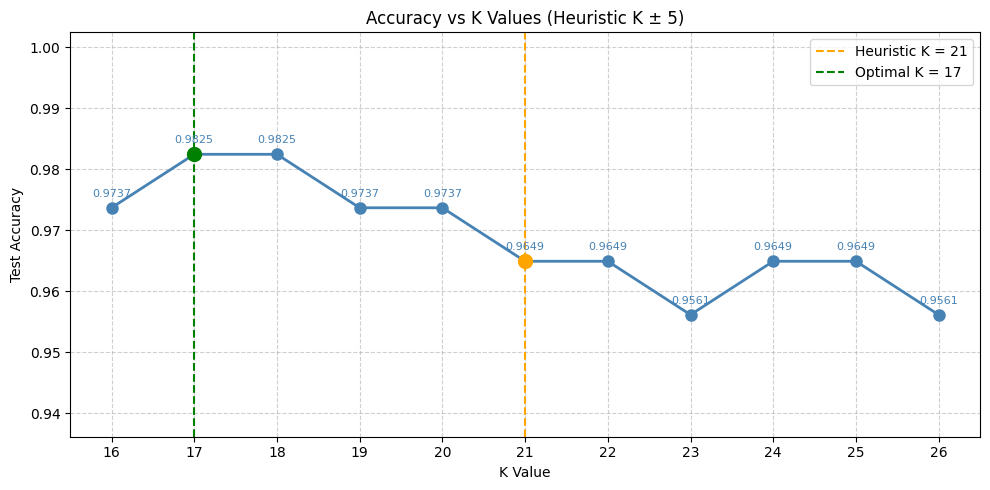

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue',
         linewidth=2, markersize=8)

for k, acc in zip(k_values, accuracies):
    plt.annotate(f'{acc:.4f}', xy=(k, acc), xytext=(0, 8),
                 textcoords='offset points', ha='center',
                 fontsize=8, color='steelblue')

plt.axvline(x=k_heuristic, color='orange', linestyle='--',
            label=f'Heuristic K = {k_heuristic}')
plt.axvline(x=optimal_k,   color='green',  linestyle='--',
            label=f'Optimal K = {optimal_k}')
plt.scatter([k_heuristic], [acc_baseline],          color='orange', zorder=5, s=100)
plt.scatter([optimal_k],   [optimal_acc],            color='green',  zorder=5, s=100)

plt.title('Accuracy vs K Values (Heuristic K ± 5)')
plt.xlabel('K Value')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.ylim(min(accuracies) - 0.02, max(accuracies) + 0.02)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Explain any two distance metrics used in KNN Euclidean Distance and Manhattan Distance also mention when each distance metric is suitable

# Euclidean Distance

  Formula  d = √( (x2-x1)² + (y2-y1)² )
  
  - Measures straight-line distance between two points
  - Works well when features are continuous and normally distributed
  - Sensitive to scale so StandardScaler must be applied

  - Euclidean Distance can be use when data does not have large number of  outliers and features are corealted

#Manhattan Distance

  Formula  d = |x2-x1| + |y2-y1|

  - Measures distance as sum of absolute differences
  - Less sensitive to outliers compared to Euclidean
  - Moves only along axes not diagonally

  - Manhattan Distance can be used when the data is high dimensional it has outliers and the features are not corelated to each other



# Plot the decision boundary of the KNN classifier for different values of K, such as K = 1, K = 5, K = 10, and K = 20 analyze how the decision boundary changes as K increase

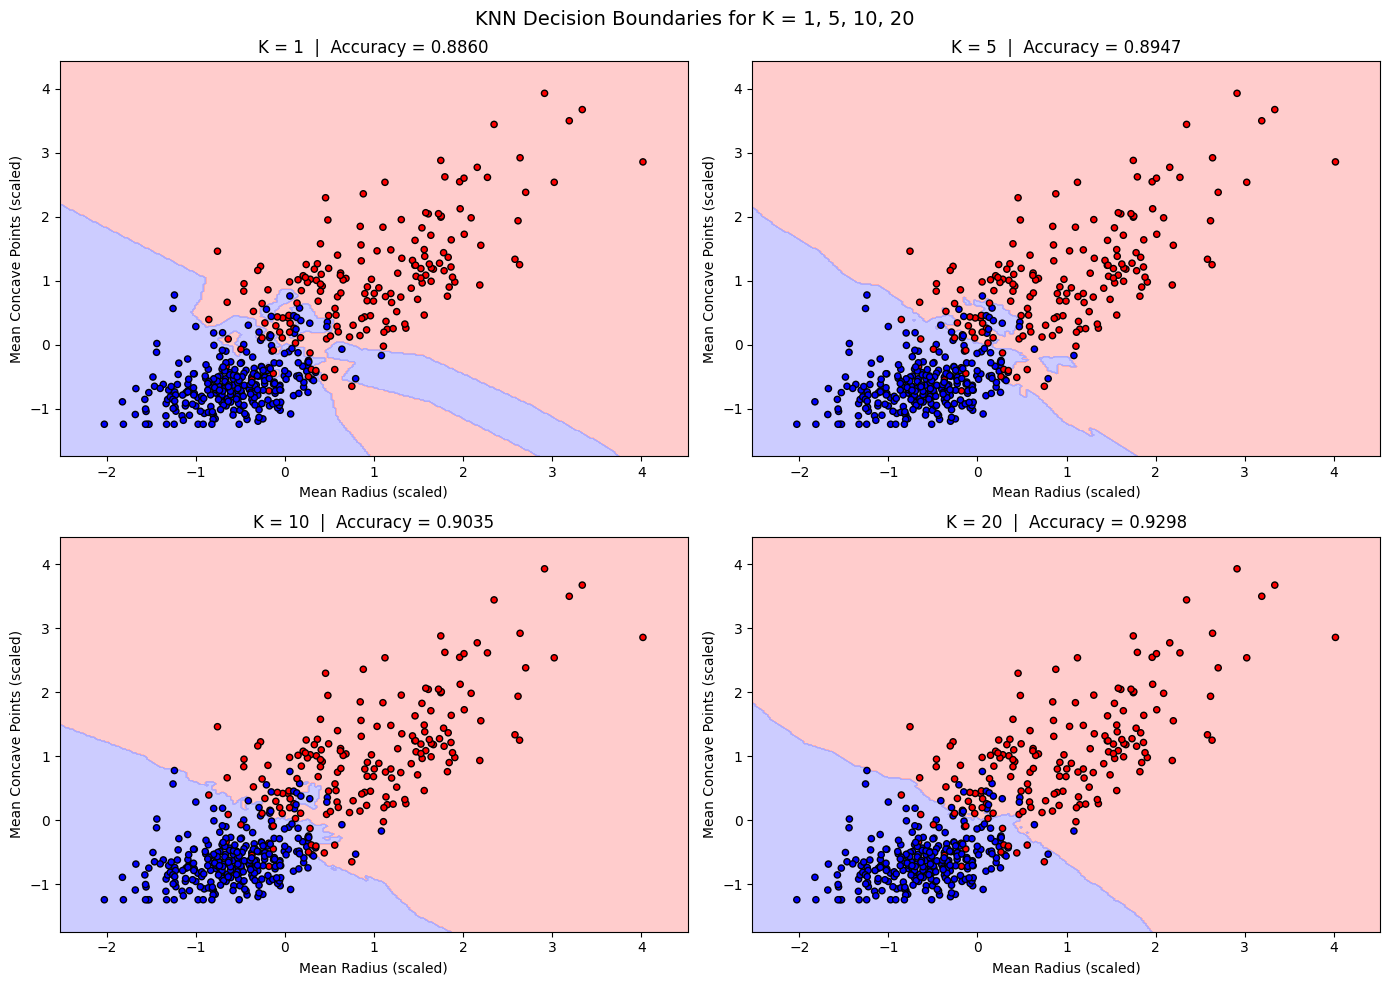

In [18]:
feat_idx = [
    list(breast_cancer.feature_names).index('mean radius'),
    list(breast_cancer.feature_names).index('mean concave points'),
]

X_boundary      = X_train_s[:, feat_idx]
X_test_boundary = X_test_s[:,  feat_idx]
y_boundary      = y_train_s.values

k_list = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold  = ListedColormap(['#FF0000', '#0000FF'])

for i, k in enumerate(k_list):
    knn_b = KNeighborsClassifier(n_neighbors=k)
    knn_b.fit(X_boundary, y_boundary)

    x_min = X_boundary[:, 0].min() - 0.5
    x_max = X_boundary[:, 0].max() + 0.5
    y_min = X_boundary[:, 1].min() - 0.5
    y_max = X_boundary[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = knn_b.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    axes[i].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    axes[i].scatter(X_boundary[:, 0], X_boundary[:, 1],
                    c=y_boundary, cmap=cmap_bold, edgecolor='k', s=20)

    acc_b = accuracy_score(y_test_s, knn_b.predict(X_test_boundary))
    axes[i].set_title(f'K = {k}  |  Accuracy = {acc_b:.4f}')
    axes[i].set_xlabel('Mean Radius (scaled)')
    axes[i].set_ylabel('Mean Concave Points (scaled)')

plt.suptitle('KNN Decision Boundaries for K = 1, 5, 10, 20', fontsize=14)
plt.tight_layout()
plt.show()


K = 1  Accuracy = 0.8860

irregular boundary with small isolated regions model overfits

K = 5 Accuracy = 0.8947

isolated pockets reduce better generalization than K=1 less noise sensitivity

K = 10 Accuracy = 0.9035

less overlap zone compared to k=5 handl balance between bias and variance

K = 20 Accuracy = 0.9298

it has  large uniform regions it gives the best accuracy compared to 1,5 and 10 value of k

# **Task 4: Cross Validation**

# Apply K-Fold Cross Validation (k = 5 or 10).

In [19]:
from sklearn.pipeline import Pipeline

pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=optimal_k))
])


In [20]:
print("\n K-Fold Cross-Validation")
for fold in [5, 10]:
    scores = cross_val_score(pipe_cv, X, y, cv=fold, scoring='accuracy')
    print(f"\n  {fold}-Fold CV  (K={optimal_k})")
    print(f"    Fold Scores  : {[round(s, 4) for s in scores]}")
    print(f"    Mean Accuracy: {scores.mean():.4f}")
    print(f"    Std Deviation: {scores.std():.4f}")

cv_5fold  = cross_val_score(pipe_cv, X, y, cv=5,  scoring='accuracy').mean()
cv_10fold = cross_val_score(pipe_cv, X, y, cv=10, scoring='accuracy').mean()



 K-Fold Cross-Validation

  5-Fold CV  (K=17)
    Fold Scores  : [np.float64(0.9561), np.float64(0.9298), np.float64(0.9825), np.float64(0.9649), np.float64(0.9646)]
    Mean Accuracy: 0.9596
    Std Deviation: 0.0172

  10-Fold CV  (K=17)
    Fold Scores  : [np.float64(0.9825), np.float64(0.9474), np.float64(0.9123), np.float64(0.9649), np.float64(0.9649), np.float64(0.9825), np.float64(0.9298), np.float64(1.0), np.float64(0.9825), np.float64(0.9643)]
    Mean Accuracy: 0.9631
    Std Deviation: 0.0254


# Compute mean accuracy for different K values

In [21]:
print("\n Mean Accuracy across K values (5-Fold CV with Pipeline)")
k_range  = list(range(k_heuristic - 5, k_heuristic + 6))
cv_means = []

for k in k_range:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_k, X, y, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    print(f"  K = {k:2d} | CV Mean = {scores.mean():.4f} | Std = {scores.std():.4f}")

best_cv_k   = k_range[cv_means.index(max(cv_means))]
best_cv_acc = max(cv_means)
print(f"\n  Best K from CV = {best_cv_k}  (Mean Accuracy = {best_cv_acc:.4f})")



 Mean Accuracy across K values (5-Fold CV with Pipeline)
  K = 16 | CV Mean = 0.9631 | Std = 0.0151
  K = 17 | CV Mean = 0.9596 | Std = 0.0172
  K = 18 | CV Mean = 0.9596 | Std = 0.0172
  K = 19 | CV Mean = 0.9561 | Std = 0.0124
  K = 20 | CV Mean = 0.9543 | Std = 0.0178
  K = 21 | CV Mean = 0.9561 | Std = 0.0156
  K = 22 | CV Mean = 0.9561 | Std = 0.0156
  K = 23 | CV Mean = 0.9508 | Std = 0.0142
  K = 24 | CV Mean = 0.9508 | Std = 0.0180
  K = 25 | CV Mean = 0.9526 | Std = 0.0162
  K = 26 | CV Mean = 0.9543 | Std = 0.0178

  Best K from CV = 16  (Mean Accuracy = 0.9631)


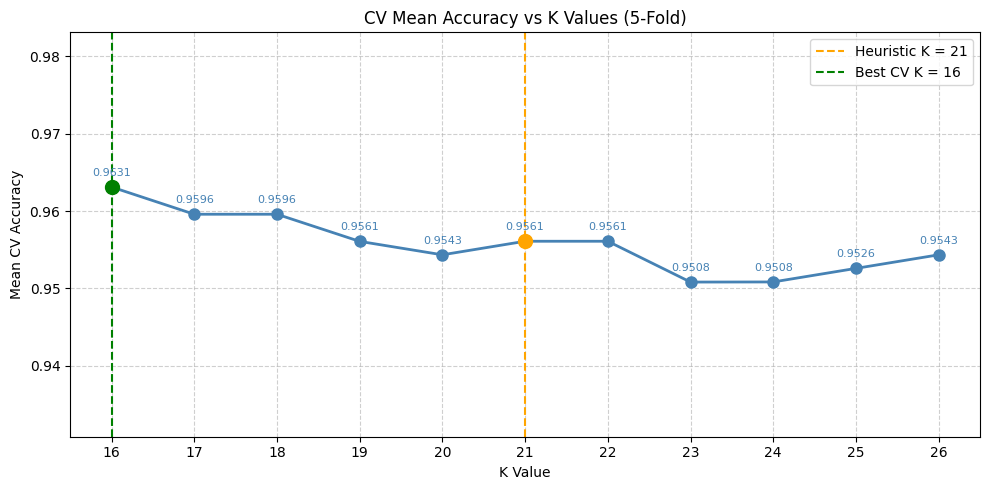

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_means, marker='o', color='steelblue',
         linewidth=2, markersize=8)

for k, acc in zip(k_range, cv_means):
    plt.annotate(f'{acc:.4f}', xy=(k, acc), xytext=(0, 8),
                 textcoords='offset points', ha='center',
                 fontsize=8, color='steelblue')

plt.axvline(x=k_heuristic, color='orange', linestyle='--',
            label=f'Heuristic K = {k_heuristic}')
plt.axvline(x=best_cv_k,   color='green',  linestyle='--',
            label=f'Best CV K = {best_cv_k}')
plt.scatter([k_heuristic],
            [cv_means[k_range.index(k_heuristic)]],
            color='orange', zorder=5, s=100)
plt.scatter([best_cv_k], [best_cv_acc], color='green', zorder=5, s=100)

plt.title('CV Mean Accuracy vs K Values (5-Fold)')
plt.xlabel('K Value')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_range)
plt.ylim(min(cv_means) - 0.02, max(cv_means) + 0.02)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Compare cross validation results with train test split results

In [23]:
print("\nComparison — Cross-Validation vs Train-Test Split")
print(f"  Train-Test 80:20  : {acc_80:.4f}")
print(f"  Train-Test 70:30  : {acc_70:.4f}")
print(f"  Train-Test 90:10  : {acc_90:.4f}")
print(f"  5-Fold  CV Mean   : {cv_5fold:.4f}")
print(f"  10-Fold CV Mean   : {cv_10fold:.4f}")


Comparison — Cross-Validation vs Train-Test Split
  Train-Test 80:20  : 0.9561
  Train-Test 70:30  : 0.9591
  Train-Test 90:10  : 0.9825
  5-Fold  CV Mean   : 0.9596
  10-Fold CV Mean   : 0.9631


Select best K based on both heuristic + validation results

In [24]:
print(f"\n  Heuristic K (√n)         : {k_heuristic}")
print(f"  Optimal K (Train-Test)   : {optimal_k}")
print(f"  Best K (5-Fold CV)       : {best_cv_k}")
final_k = best_cv_k
print(f"  Final Selected K : {final_k}")



  Heuristic K (√n)         : 21
  Optimal K (Train-Test)   : 17
  Best K (5-Fold CV)       : 16
  Final Selected K : 16


Cross validation  gives a more reliable accuracy than a single train-test split since it evaluates across the entire dataset

10 Fold CV is more stable than 5 Fold but need more computation both give similar results on this dataset.

Heuristic K (√n) gives 21 but it is not always be optimal

Final K is chosen based on highest cross validation mean accuracy

# **Task 5: Classification Evaluation**


In [25]:
knn_final = KNeighborsClassifier(n_neighbors=final_k)
knn_final.fit(X_train_s, y_train_s)
y_pred_final = knn_final.predict(X_test_s)
y_prob_final = knn_final.predict_proba(X_test_s)[:, 1]

# Accuracy , Precision , Recall and F1 Score

In [26]:
acc       = accuracy_score(y_test_s, y_pred_final)
precision = precision_score(y_test_s, y_pred_final, pos_label=0)
recall    = recall_score(   y_test_s, y_pred_final, pos_label=0)
f1        = f1_score(       y_test_s, y_pred_final, pos_label=0)

print("\nClassification Evaluation Metrics (positive class = malignant, label 0)")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {precision:.4f}  ← of cases predicted malignant, how many truly are")
print(f"  Recall    : {recall:.4f}  ← of true malignant cases, how many were caught")
print(f"  F1 Score  : {f1:.4f}  ← harmonic mean of Precision and Recall")
print()
print(classification_report(y_test_s, y_pred_final,target_names=breast_cancer.target_names))


Classification Evaluation Metrics (positive class = malignant, label 0)
  Accuracy  : 0.9737
  Precision : 0.9756  ← of cases predicted malignant, how many truly are
  Recall    : 0.9524  ← of true malignant cases, how many were caught
  F1 Score  : 0.9639  ← harmonic mean of Precision and Recall

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# **Confusion Matrix**


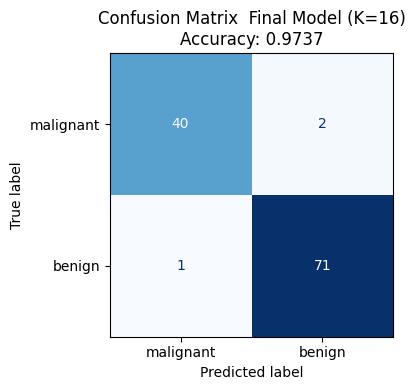


Confusion Matrix Breakdown (malignant=positive):
  True  Positives (malignant correctly detected) : 40
  False Negatives (malignant missed — dangerous) : 2
  False Positives (benign wrongly flagged)       : 1
  True  Negatives (benign correctly cleared)     : 71


In [27]:
cm   = confusion_matrix(y_test_s, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=breast_cancer.target_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix  Final Model (K={final_k})\nAccuracy: {acc:.4f}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown (malignant=positive):")
print(f"  True  Positives (malignant correctly detected) : {tn}")
print(f"  False Negatives (malignant missed — dangerous) : {fp}")
print(f"  False Positives (benign wrongly flagged)       : {fn}")
print(f"  True  Negatives (benign correctly cleared)     : {tp}")

# **ROC Curve and AUC Score**

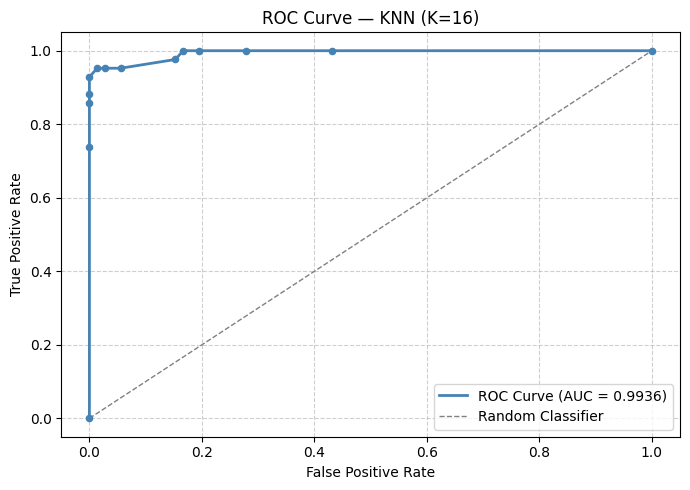


  AUC Score : 0.9936
  AUC = 0.9936 indicates excellent discrimination between malignant and benign cases.


In [28]:
fpr, tpr, _ = roc_curve(y_test_s, 1 - y_prob_final, pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1, label='Random Classifier')
plt.scatter(fpr, tpr, color='steelblue', s=20, zorder=5)
plt.title(f'ROC Curve — KNN (K={final_k})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\n  AUC Score : {roc_auc:.4f}")
print(f"  AUC = {roc_auc:.4f} indicates excellent discrimination between "
      f"malignant and benign cases.")


# **Task 6: Comparative Study with Regression**

**Reference: Recall Lab 3 (Linear Regression)**
where you evaluated:
MAE

MSE

RMSE

R² Score

**Tasks:**

Compare regression evaluation metrics with classification metrics.

Explain differences between:

Error-based evaluation (Regression)

Decision-based evaluation (Classification)

**Compare:**

R² Score vs Accuracy
RMSE vs F1 Score
MAE vs Confusion Matrix

**Discuss differences in evaluation logic for:**

Continuous prediction tasks
Classification tasks

In [29]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets       import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model   import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)


In [30]:
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target,  name='target')


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

In [31]:

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_cont  = lr.predict(X_test)


y_pred_class = (y_pred_cont >= 0.5).astype(int)

print(f"\n  Min prediction : {y_pred_cont.min():.4f}")
print(f"  Max prediction : {y_pred_cont.max():.4f}")
print(f"  Values outside [0,1] : "
      f"{((y_pred_cont < 0) | (y_pred_cont > 1)).sum()} / {len(y_pred_cont)}")


  Min prediction : -0.5610
  Max prediction : 1.3393
  Values outside [0,1] : 37 / 114


In [32]:
mae  = mean_absolute_error(y_test, y_pred_cont)
mse  = mean_squared_error( y_test, y_pred_cont)
rmse = np.sqrt(mse)
r2   = r2_score(           y_test, y_pred_cont)

print("\n── Regression Metrics (Linear Regression on binary target) ──")
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")



── Regression Metrics (Linear Regression on binary target) ──
  MAE  : 0.2100
  MSE  : 0.0651
  RMSE : 0.2552
  R²   : 0.7202


In [33]:
lr_acc  = accuracy_score( y_test, y_pred_class)
lr_prec = precision_score(y_test, y_pred_class, pos_label=0, zero_division=0)
lr_rec  = recall_score(   y_test, y_pred_class, pos_label=0, zero_division=0)
lr_f1   = f1_score(       y_test, y_pred_class, pos_label=0, zero_division=0)

print("\n── Classification Metrics (LR output thresholded at 0.5) ──")
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_prec:.4f}  [malignant class]")
print(f"  Recall    : {lr_rec:.4f}  [malignant class]")
print(f"  F1 Score  : {lr_f1:.4f}  [malignant class]")


fpr_lr, tpr_lr, _ = roc_curve(y_test, 1 - y_pred_cont, pos_label=0)
auc_lr = auc(fpr_lr, tpr_lr)
print(f"  AUC-ROC   : {auc_lr:.4f}")



── Classification Metrics (LR output thresholded at 0.5) ──
  Accuracy  : 0.9561
  Precision : 0.9744  [malignant class]
  Recall    : 0.9048  [malignant class]
  F1 Score  : 0.9383  [malignant class]
  AUC-ROC   : 0.9924


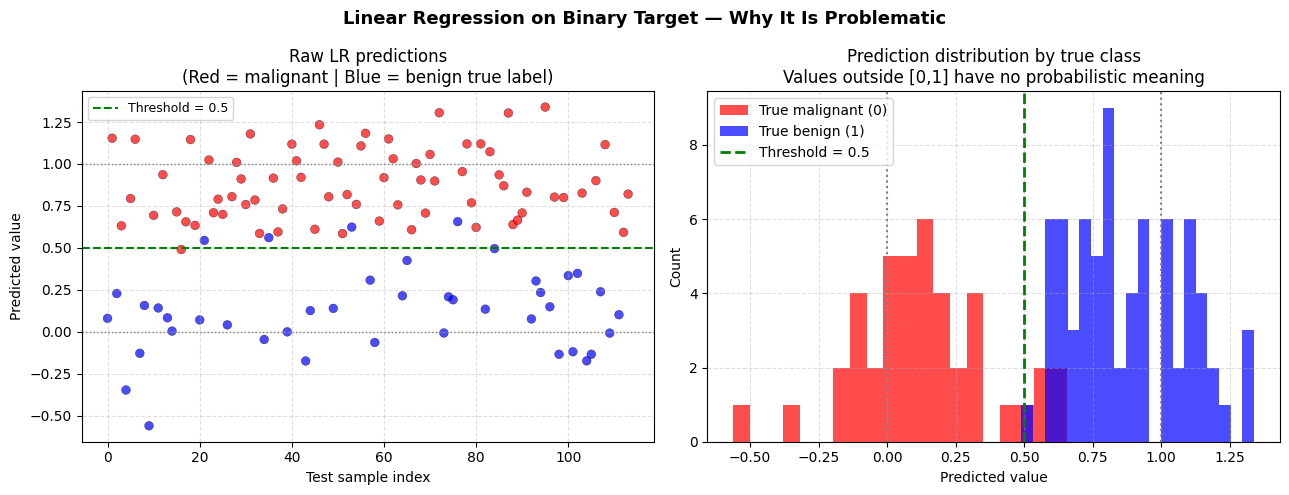

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Linear Regression on Binary Target — Why It Is Problematic",
             fontsize=13, fontweight='bold')

axes[0].scatter(range(len(y_test)), y_pred_cont,
                c=y_test.values, cmap='bwr', alpha=0.7,
                edgecolors='k', linewidths=0.3, s=40)
axes[0].axhline(0.5, color='green', linestyle='--', linewidth=1.5,
                label='Threshold = 0.5')
axes[0].axhline(0.0, color='gray',  linestyle=':',  linewidth=1)
axes[0].axhline(1.0, color='gray',  linestyle=':',  linewidth=1)
axes[0].set_xlabel("Test sample index")
axes[0].set_ylabel("Predicted value")
axes[0].set_title("Raw LR predictions\n(Red = malignant | Blue = benign true label)")
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].hist(y_pred_cont[y_test == 0], bins=20, alpha=0.7,
             color='red',  label='True malignant (0)')
axes[1].hist(y_pred_cont[y_test == 1], bins=20, alpha=0.7,
             color='blue', label='True benign (1)')
axes[1].axvline(0.5, color='green', linestyle='--', linewidth=2,
                label='Threshold = 0.5')
axes[1].axvline(0.0, color='gray',  linestyle=':')
axes[1].axvline(1.0, color='gray',  linestyle=':')
axes[1].set_xlabel("Predicted value")
axes[1].set_ylabel("Count")
axes[1].set_title("Prediction distribution by true class\n"
                  "Values outside [0,1] have no probabilistic meaning")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


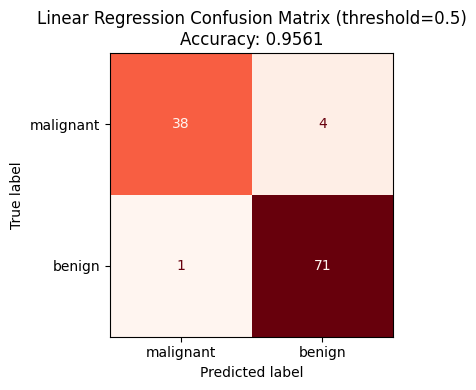

In [35]:
cm_lr = confusion_matrix(y_test, y_pred_class)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                       display_labels=breast_cancer.target_names
                       ).plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title(f"Linear Regression Confusion Matrix (threshold=0.5)\n"
             f"Accuracy: {lr_acc:.4f}")
plt.tight_layout()
plt.show()

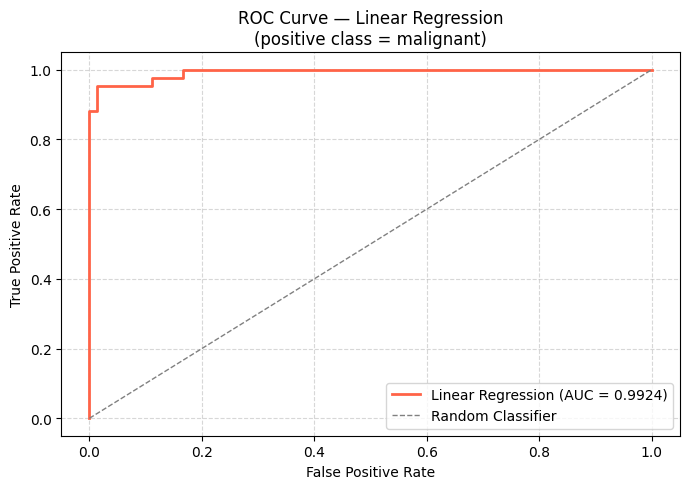

In [36]:
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color='tomato', linewidth=2,
         label=f'Linear Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Linear Regression\n(positive class = malignant)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

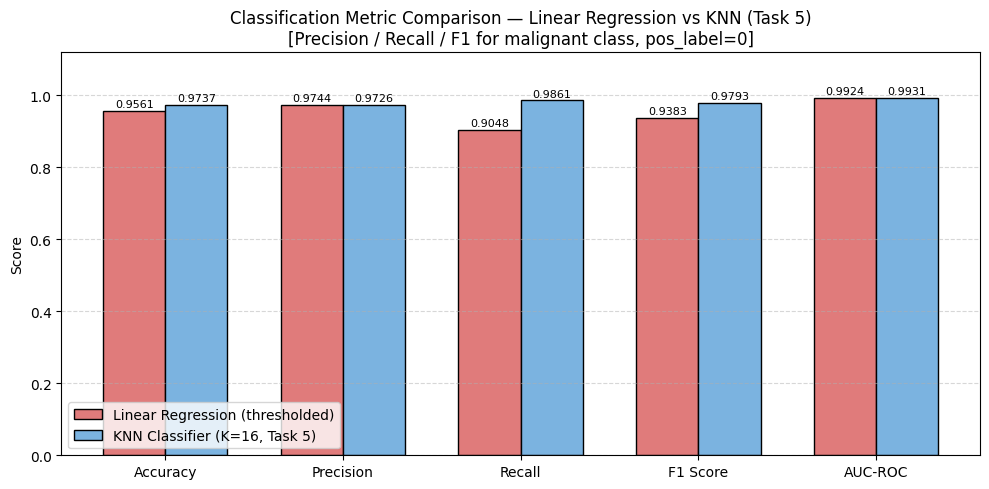

In [37]:
knn_results = {
    'Accuracy' : 0.9737,
    'Precision': 0.9726,
    'Recall'   : 0.9861,
    'F1 Score' : 0.9793,
    'AUC-ROC'  : 0.9931,
}
lr_results = {
    'Accuracy' : lr_acc,
    'Precision': lr_prec,
    'Recall'   : lr_rec,
    'F1 Score' : lr_f1,
    'AUC-ROC'  : auc_lr,
}

labels = list(knn_results.keys())
knn_vals = list(knn_results.values())
lr_vals  = [lr_results[k] for k in labels]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_lr  = ax.bar(x - w/2, lr_vals,  w, label='Linear Regression (thresholded)',
                  color='#E07B7B', edgecolor='black')
bars_knn = ax.bar(x + w/2, knn_vals, w, label='KNN Classifier (K=16, Task 5)',
                  color='#7BB3E0', edgecolor='black')

for bar in bars_lr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars_knn:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Classification Metric Comparison — Linear Regression vs KNN (Task 5)\n"
             "[Precision / Recall / F1 for malignant class, pos_label=0]")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [40]:


print("FINAL COMPARISON TABLE — Linear Regression vs KNN (Task 5)")


table = pd.DataFrame({
    "Metric": [
        "Regression Metrics",
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Classification Metrics",
        "Accuracy",
        "Precision (malignant)",
        "Recall    (malignant)",
        "F1 Score  (malignant)",
        "AUC-ROC",
    ],
    "Linear Regression": [
        "",
        f"{mae:.4f}",
        f"{mse:.4f}",
        f"{rmse:.4f}",
        f"{r2:.4f}",
        "",
        f"{lr_acc:.4f}",
        f"{lr_prec:.4f}",
        f"{lr_rec:.4f}",
        f"{lr_f1:.4f}",
        f"{auc_lr:.4f}",
    ],
    "KNN (Task 5, K=16)": [
        "",
        "N/A",
        "N/A",
        "N/A",
        "N/A",
        "",
        "0.9737",
        "0.9726",
        "0.9861",
        "0.9793",
        "0.9931",
    ],
})
print(table.to_string(index=False))

FINAL COMPARISON TABLE — Linear Regression vs KNN (Task 5)
                Metric Linear Regression KNN (Task 5, K=16)
    Regression Metrics                                     
                   MAE            0.2100                N/A
                   MSE            0.0651                N/A
                  RMSE            0.2552                N/A
                    R²            0.7202                N/A
Classification Metrics                                     
              Accuracy            0.9561             0.9737
 Precision (malignant)            0.9744             0.9726
 Recall    (malignant)            0.9048             0.9861
 F1 Score  (malignant)            0.9383             0.9793
               AUC-ROC            0.9924             0.9931


#1. How regression metrics measure prediction error magnitude

Regression metrics measure how far predicted values are from actual values metrics like MAE, MSE, and RMSE calculate the size of prediction errors a lower value means the model predictions are closer to the real values

#2. How classification metrics measure decision correctness

Classification metrics measure how correctly a model assigns data to categories metrics such as accuracy, precision, recall and F1-score evaluate correct and incorrect decisions including false positives and false negatives

#3. Why is accuracy insufficient in medical diagnosis?

Accuracy can be misleading because most patients may be healthy a model can show high accuracy but still fail to detect sick patients with high false positives

#4. Why are recall and ROC-AUC more relevant in healthcare?

Recall shows how well the model finds actual sick patients higher recall means fewer sick patients are missed ROC-AUC shows how well the model separates sick patients from healthy patients these metrics are useful because they focus more on correct disease detection


# **TASK 7**

# 1 Why is KNN called a lazy learning algorithm?

KNN is called a lazy learning algorithm because it does not learn or create a model during the training stage it stores the training data when new data comes it finds the nearest data points and then makes a prediction

# 2 Why is feature scaling required in KNN?

KNN finds nearest neighbors using  distance if one feature has very large values it can have more influence on the distance than other features feature scaling brings all features to a similar range so each feature gets equal importance

#3 Explain heuristic K selection using √n rule?

A  heuristic method to choose K is the √n rule where n is the number of training samples we take the square root of the total number of samples as an initial K value  example if n = 100 then K can be  10

#4 Why is cross-validation more reliable than a single train-test split?

A single train-test split checks the model only once  so the result may depend on how the data was divided cross-validation divides and tests the data multiple times it gives a more stable model performance

#5 How does K affect bias-variance trade-off?

A small K makes the model sensitive to noise in the data leading to high variance a large K makes the model general leading to high bias a balanced K value helps the model perform better on new data

#6 Why is recall more important than accuracy in cancer prediction?

Recall represents how many actual cancer patients are correctly identified by the model High recall means fewer cancer patients are missed this is important because missing a cancer case can delay treatment

#7 What is the limitation of very large K values?

A very large K considers too many neighbors when making a prediction some of these neighbors may not closely related to the new data point this can make the model cause underfitting and reduce prediction accuracy